In [1]:
import os
import joblib
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.metrics import silhouette_score
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Open a file upload dialog
uploaded = files.upload()

Saving Cleaned Dataset.csv to Cleaned Dataset.csv


In [3]:
dataset = pd.read_csv("Cleaned Dataset.csv")

In [4]:
dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),BEV (New Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),...,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_Available,Log_DC Recharging Speed (km/h),YJ_Purchase price (EUR)
0,Austria,2011,0.18,631.0,308167.0,3.286579,1.6,963,17.500000,175.000000,...,95.00,30469.93,0.165514,6.448889,6.871091,12.638400,1.455489,1.609438,5.170484,-1.493084
1,Austria,2012,0.13,427.0,316589.4,2.485676,1.0,1063,29.169521,217.394139,...,95.00,30469.93,0.122218,6.059123,6.969791,12.665364,1.248662,1.609438,5.386301,-1.493084
2,Austria,2013,0.21,656.0,321191.7,2.000156,0.4,1173,48.200000,270.000000,...,142.22,30469.93,0.190620,6.487684,7.068172,12.679797,1.098664,2.197225,5.602119,-1.493084
3,Austria,2014,0.44,1344.0,330113.5,1.605812,1.0,1393,22.600000,240.000000,...,155.77,35555.64,0.364643,7.204149,7.239933,12.707195,0.957744,2.639057,5.484797,-0.885657
4,Austria,2015,0.55,1699.0,342083.5,0.896563,0.6,1625,47.700000,381.250000,...,215.22,42052.00,0.438255,7.438384,7.393878,12.742813,0.640043,3.091042,5.946075,0.277809


In [5]:
dataset.columns

Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)'],
      dtype='object')

# Feature Selection

The feature selection is done only on the pre-covid data. This could help us answer a real world hypothesis question - "Can the economic and technical rules of the 2010s predict the explosive growth of the 2020s?"

This also brings up another question because we have averages. It becomes mathematically impossible for the model to "split" the credit: "Did sales go up because the range improved, or because the battery got bigger?"

In [6]:
# Split the dataset pre and post covid
pre_covid = dataset[dataset['Year'].between(2011, 2019)].copy()
post_covid = dataset[dataset['Year'].between(2020, 2024)].copy()

In [7]:
features = [
    'Log_Recharging Points',
    'Real Range',
    'Log_Available',
    'YJ_Purchase price (EUR)',
    'AC Recharging Speed (km/h)',
    'Battery Capacity',
    'Log_DC Recharging Speed (km/h)',
    'EG',
    'Log_GDP',
    'Log_CPI'
]

**1. Heat Maps with Pearson Correlation**

Helps in understanding correlation of the features pre-covid.

Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on Pre-COVID dataset:

Log_Recharging Points             0.882882
Log_GDP                           0.556929
Log_Available                     0.469013
Real Range                        0.444322
YJ_Purchase price (EUR)           0.437179
Battery Capacity                  0.386406
AC Recharging Speed (km/h)        0.374980
Log_DC Recharging Speed (km/h)    0.359244
EG                                0.193489
Log_CPI                          -0.027741
Name: Log_BEV (New Registrations), dtype: float64


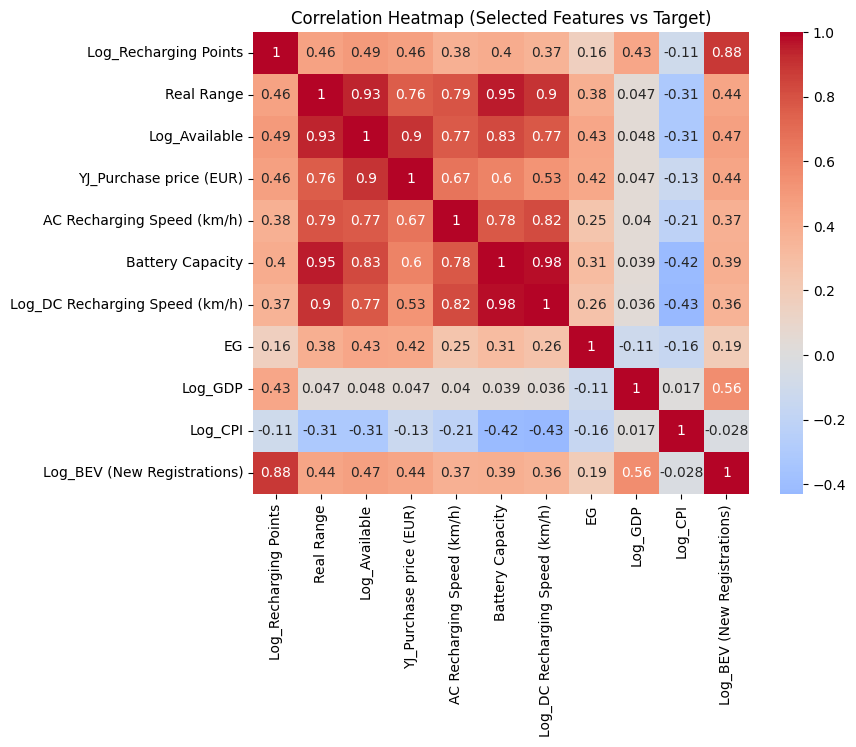

In [8]:
# Define the target
target = 'Log_BEV (New Registrations)'

# Compute correlation only for selected features + target
corr = pre_covid[features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)

# Drop the target itself if it appears
corr = corr.drop(labels=[target], errors='ignore')

# Display correlations
print("Correlation of selected features with Log_BEV Percentage (Total Number Of Registrations) on Pre-COVID dataset:\n")
print(corr)

# Visualize heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pre_covid[features + [target]].corr(numeric_only=True),
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Selected Features vs Target)")
plt.show()

In [9]:
pre_covid[['Log_BEV Percentage (Total Number Of Registrations)',
         'Log_BEV (New Registrations)']].corr()

,Log_BEV Percentage (Total Number Of Registrations),Log_BEV (New Registrations)
Log_BEV Percentage (Total Number Of Registrations),1.00000,0.61186
Log_BEV (New Registrations),0.61186,1.00000


**2. Multicollinearity**

Removal of redundant features

In [10]:
pre_covid_features = dataset[features].dropna().reset_index(drop=True)

pre_covid_vif_data = pd.DataFrame()
pre_covid_vif_data["Feature"] = pre_covid_features.columns
pre_covid_vif_data["VIF"] = [variance_inflation_factor(pre_covid_features.values, i) for i in range(pre_covid_features.shape[1])]
print(pre_covid_vif_data)

                          Feature         VIF
0           Log_Recharging Points   17.045261
1                      Real Range  537.361825
2                   Log_Available  115.978308
3         YJ_Purchase price (EUR)    4.666438
4      AC Recharging Speed (km/h)   39.427131
5                Battery Capacity  271.273113
6  Log_DC Recharging Speed (km/h)  131.906094
7                              EG    1.782205
8                         Log_GDP   56.511499
9                         Log_CPI    3.290362


**Observation**

A lower VIF values does not guarantee that the feature is highly correlated with the target.

For example: EG with a lower VIF=1.782205 also has a lower correlation values in Heatmaps. **Meaning:** it is unique and not overlapping with other variables. "Unique but Unhelpful" yet we can keep it cause its giving a new perspective.
    
But, Log_Recharging Points with a higher VIF=17.045261 also has the strongest correlation with your target.

Moreover, Battery Capacity with a VIF=271.273113 because it is likely tied to Real Range and Purchase Price and also is has a correlation of 0.4. Its high VIF suggests it might be redundant if you already have Real Range in the model.

**3. Principal Component Analysis (PCA)**

To reduce the dimensions and deal with multicollinearity. This also will help us resolve the conflict of high correlation with sales but also high VIF.

**Refer paper : A Tutorial on Principal Component Analysisn to understand the PCA concept**

## Mathematics For PCA

**Step 1: Covariance Matrix**  
Calculates the covariance matrix for the features to see the relationship among themselves. Since we also have average features like "Real Range" and "Battery Capacity" which go hand in hand as verfied previously using heatmap and VIF.

**Step 2: Eigen Value decomposition and determine Eigen Vectors**
Formula: determinant|(A - $\lambda$.I)| = 0

**Step 3: Normalise the Eigen Vectors**
Point to remember: Discarding the eigenvector v2 and so on, will reduce dimensionality leading to loss of information. Therefore here we used Elbow Method to get the significant eigen vectors to prevent this.

**Step 4: Find the Principal Components**
Here,  the aim is to use the feature vector formed using the eigenvectors of the covariance matrix, to reorient the data from the original axes to the ones represented by the principal components (hence the name Principal Components Analysis).

Formula: Final Dataset = Feature Vector (Step 3) * Normalised Original Dataset (Step 3)

In [11]:
# Check which columns have NaNs and how many
print("Missing Values Per Column (Pre-COVID)")
print(pre_covid[features].isna().sum())

print("\nMissing Values Per Column (Post-COVID)")
print(post_covid[features].isna().sum())

Missing Values Per Column (Pre-COVID)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           8
dtype: int64

Missing Values Per Column (Post-COVID)
Log_Recharging Points             0
Real Range                        0
Log_Available                     0
YJ_Purchase price (EUR)           0
AC Recharging Speed (km/h)        0
Battery Capacity                  0
Log_DC Recharging Speed (km/h)    0
EG                                0
Log_GDP                           0
Log_CPI                           1
dtype: int64


In [12]:
# Checking which rows are empty
print("Missing Log_CPI in Pre-COVID")
print(pre_covid[pre_covid['Log_CPI'].isna()].reset_index()[['Country', 'Year', 'Log_CPI']])
print("\n")
print("Missing Log_CPI in Post-COVID")
print(post_covid[post_covid['Log_CPI'].isna()].reset_index()[['Country', 'Year', 'Log_CPI']])

Missing Log_CPI in Pre-COVID
    Country  Year  Log_CPI
0  Bulgaria  2014      NaN
1   Croatia  2016      NaN
2    Cyprus  2014      NaN
3    Cyprus  2015      NaN
4    Cyprus  2016      NaN
5    Greece  2014      NaN
6    Greece  2015      NaN
7   Romania  2016      NaN


Missing Log_CPI in Post-COVID
  Country  Year  Log_CPI
0  Greece  2020      NaN


In [13]:
# Imputation for Log_CPI NaNs by filling the spaces with the median

# Calculate the median Log_CPI for every country of Pre-COVID data
country_medians = pre_covid.groupby('Country')['Log_CPI'].median()

# Function to fill the gaps
def impute_by_country(df):
    df_clean = df.copy()

    # Loop through the data, if Log_CPI is missing, we look up that specific country's median from our 'country_medians' list.
    df_clean['Log_CPI'] = df_clean['Log_CPI'].fillna(df_clean['Country'].map(country_medians))

    return df_clean

# Apply the fix to both datasets
pre_covid_fixed = impute_by_country(pre_covid)
post_covid_fixed = impute_by_country(post_covid)

# Extract 10 features
X_train_imputed = pre_covid_fixed[features]
X_test_imputed = post_covid_fixed[features]

**Reason for imputing with median:** Using a mean here, would technically be incorrect because the years missing is between the time frame 2011-2019 where there is a steady growth. Mean would pull the value to a higher margin showing a "hyperinflation" out of no where.

The median value ignores those crazy spikes and gives you a much more realistic inflation value for Europe.

In [14]:
# Standard Scaling to bring everything in one unit after imputing the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

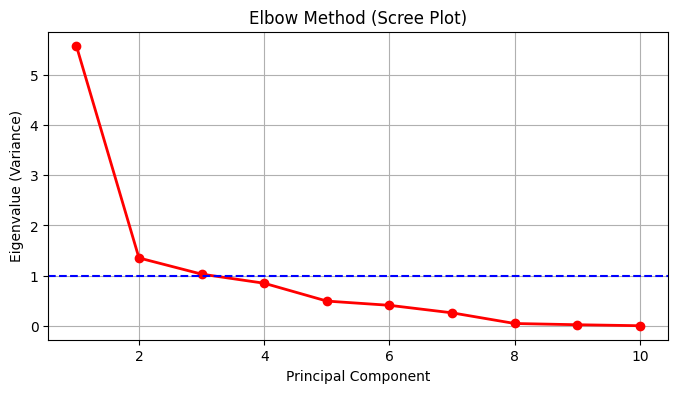

In [15]:
# Elbow Method to justify the number of components
pca_full = PCA() # We fit all 10 components first to see the curve
pca_full.fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'ro-', linewidth=2)
plt.axhline(y=1, color='blue', linestyle='--')
plt.title('Elbow Method (Scree Plot)')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (Variance)')
plt.grid(True)
plt.show()

The logic here is we have kept only those eigenvalues which above the "elbow" (or above lambda = 1).

Mathematically discarding the Eigenvectors v4 to v10.

In [16]:
# PCA: fit on Pre-COVID; project Post-COVID into that same space
principal_components = 3 # Based on the elbow method for not missing out on any features
pca = PCA(n_components=principal_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

We calculate the covariance matrix and the Eigen values on the pre-covid dataset.
1. This identifies relationship between variables like Real Range and Battery Capacity.
2. The Eigenvalues tell you which patterns were the strongest before the pandemic. For example, if "GDP" was the biggest driver of variance in 2015, the Eigenvector associated with the largest $\lambda$ will point toward GDP.

In [17]:
# Convert to Final Dataset for your Prediction Model
pc_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

X_train_final = pd.DataFrame(X_train_pca, columns=pc_columns, index=pre_covid.index)
X_test_final = pd.DataFrame(X_test_pca, columns=pc_columns, index=post_covid.index)

In [18]:
# Define target
y_train = pre_covid['Log_BEV Percentage (Total Number Of Registrations)']
y_test = post_covid['Log_BEV Percentage (Total Number Of Registrations)']

print(f"{len(features)} features reduced to {len(pc_columns)} Principal Components.")
print(f"Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

10 features reduced to 3 Principal Components.
Variance Explained: 79.36%


**For Train:** Python takes the 2011–2019 data and multiplies it by the top 3 Eigenvectors to get the X_train_final coordinates.

**For Test:** Code does not solve $|A - lambda I| = 0 for the Test set. Instead, it takes the Feature Vector (Eigenvectors) discovered in the Training set and multiplies it by the 2020–2024 data. This prevents data leakage.

In [19]:
# Check which PC is the strongest predictor of sales
pc_correlation = X_train_final.corrwith(y_train)
print("Correlation of Principal Components with BEV Sales:")
print(pc_correlation.sort_values(ascending=False))

Correlation of Principal Components with BEV Sales:
PC1    0.485616
PC3    0.264141
PC2    0.205617
dtype: float64


In [20]:
# Features along with their weights in each principal component columns explaining their variance.
loadings_table = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)

# Display the final table
print("Loading factors of the parameters selected (Feature Weights)")
print(loadings_table.round(4))

Loading factors of the parameters selected (Feature Weights)
                                   PC1     PC2     PC3
Log_Recharging Points           0.2287  0.5549  0.0854
Real Range                      0.4103 -0.0377 -0.0013
Log_Available                   0.4039 -0.0085  0.1481
YJ_Purchase price (EUR)         0.3434  0.0470  0.3890
AC Recharging Speed (km/h)      0.3624 -0.0171 -0.0221
Battery Capacity                0.3964 -0.0808 -0.2095
Log_DC Recharging Speed (km/h)  0.3832 -0.0899 -0.2862
EG                              0.1860 -0.2372  0.5237
Log_GDP                         0.0380  0.7545 -0.1598
Log_CPI                        -0.1642  0.2189  0.6272


**Loading Factors:** Is the literal Feature Vector from Step 3. It shows exactly how much "weight" each original feature (like Battery Capacity) has in creating PC1, PC2, and PC3.

Values which are close to -1 or +1 are the drivers for that PC. If 0, then thatfeature has almost no influence on that component.

**Interpretation of the Results:**

PC1 (Vehicle Capability): Real Range, Log_Available, Battery Capacity, Log_DC Recharging Speed (km/h)

PC2 (Economic & Infrastructure): Log_GDP, Log_Recharging Points

PC3 (Cost & Inflation): Log_CPI, EG, YJ_Purchase price (EUR)

In [21]:
# To confirm that all the principal components are independent of each other.
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_final.columns

# Calculate VIF for each Principal Component
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i)
                   for i in range(len(X_train_final.columns))]

print("VIF for Principal Components")
print(vif_data)

VIF for Principal Components
  Feature  VIF
0     PC1  1.0
1     PC2  1.0
2     PC3  1.0


In [22]:
# Saving the PCA model
# Define filenames
csv_files = ['X_train_pca.csv', 'X_test_pca.csv', 'y_train.csv', 'y_test.csv']
pkl_file = 'pca_processors.pkl'

# Save the processed Datasets
X_train_final.to_csv(csv_files[0], index=True)
X_test_final.to_csv(csv_files[1], index=True)
y_train.to_csv(csv_files[2], index=True)
y_test.to_csv(csv_files[3], index=True)

# Save the PCA
pca_processing_tools = {
    'country_medians': country_medians,
    'scaler': scaler,
    'pca_model': pca,
    'feature_names': features
}
joblib.dump(pca_processing_tools, pkl_file)

# Just to be sure print the exact file locations
print(f"Folder Location: {os.getcwd()}")
print("-" * 30)

for file in csv_files + [pkl_file]:
    full_path = os.path.abspath(file)
    print(f"Saved: {file}")
    print(f"Full Path: {full_path}\n")

Folder Location: /content
------------------------------
Saved: X_train_pca.csv
Full Path: /content/X_train_pca.csv

Saved: X_test_pca.csv
Full Path: /content/X_test_pca.csv

Saved: y_train.csv
Full Path: /content/y_train.csv

Saved: y_test.csv
Full Path: /content/y_test.csv

Saved: pca_processors.pkl
Full Path: /content/pca_processors.pkl



# Clustering

In [23]:
# Load PCA tools and feature definitions
tools = joblib.load("pca_processors.pkl")

scaler = tools['scaler']
pca = tools['pca_model']
country_medians = tools['country_medians']
features = tools['feature_names']

Understanding data pre and post covid

In [24]:
pre_covid = dataset[dataset['Year'].between(2011, 2019)].copy()
post_covid = dataset[dataset['Year'].between(2020, 2024)].copy()

In [25]:
# Aggregate numeric features per country
pre_country = pre_covid.groupby('Country')[features].mean(numeric_only=True)
post_country = post_covid.groupby('Country')[features].mean(numeric_only=True)

print(f"Pre-COVID dataset shape: {pre_country.shape}")
print(f"Post-COVID dataset shape: {post_country.shape}")

Pre-COVID dataset shape: (27, 10)
Post-COVID dataset shape: (27, 10)


1. Each country now appears once per period.
2. Each feature represents that country’s average condition during the period (pre/post COVID).

In [26]:
# Apply the same scaling and PCA
X_pre_scaled = scaler.transform(pre_country)
X_post_scaled = scaler.transform(post_country)

X_pre_pca = pca.transform(X_pre_scaled)
X_post_pca = pca.transform(X_post_scaled)

print(f"PCA-transformed shapes: Pre={X_pre_pca.shape}, Post={X_post_pca.shape}")

PCA-transformed shapes: Pre=(27, 3), Post=(27, 3)


## 1. K-Means

**Refer paper: Analysis of Techniques for Selecting Appropriate Number of Clusters in k-means Clustering Algorithm** to cite why I chose these 2 methods.

Elbow Method

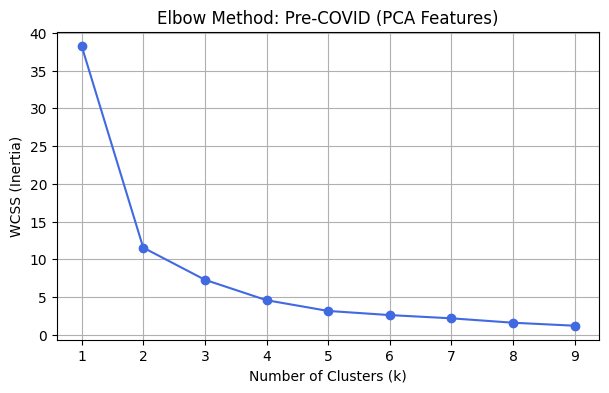

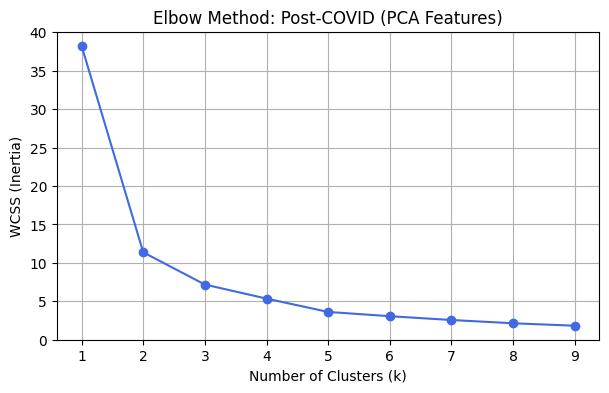

In [27]:
# Elbow Method (to find optimal k)
def plot_elbow(X, label):
    inertia = []
    K_range = range(1, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, inertia, 'o-', color='royalblue')
    plt.title(f'Elbow Method: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.grid(True)
    plt.show()

plot_elbow(X_pre_pca, "Pre-COVID (PCA Features)")
plot_elbow(X_post_pca, "Post-COVID (PCA Features)")

Use of SILHOUETTE method to verify the #clusters in eblow method

**This is the validation method to the elbow method.**

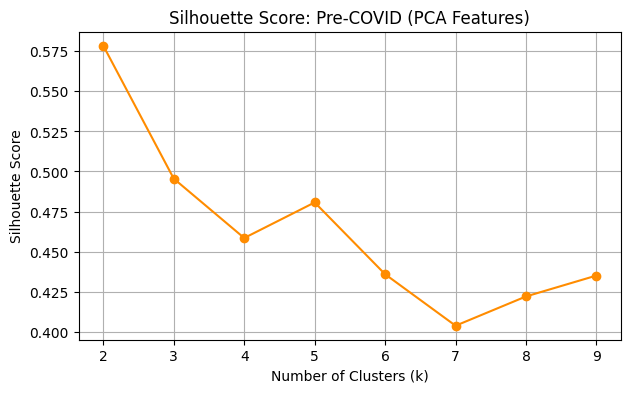

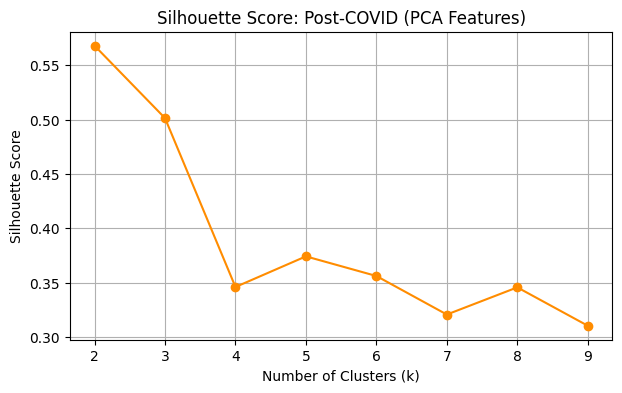

In [28]:
# Silhouette Method (to validate optimal k)
def plot_silhouette(X, label):
    sil_scores = []
    K_range = range(2, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
    plt.figure(figsize=(7, 4))
    plt.plot(K_range, sil_scores, 'o-', color='darkorange')
    plt.title(f'Silhouette Score: {label}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

plot_silhouette(X_pre_pca, "Pre-COVID (PCA Features)")
plot_silhouette(X_post_pca, "Post-COVID (PCA Features)")

In [29]:
# Final Clustering
n_clusters = 2

kmeans_pre = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_post = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

pre_country['Cluster'] = kmeans_pre.fit_predict(X_pre_pca)
post_country['Cluster'] = kmeans_post.fit_predict(X_post_pca)

In [30]:
# Compare cluster memberships pre vs post COVID
cluster_compare = pre_country[['Cluster']].rename(columns={'Cluster': 'Pre_COVID_Cluster'})
cluster_compare['Post_COVID_Cluster'] = post_country['Cluster']
print(cluster_compare)

                Pre_COVID_Cluster  Post_COVID_Cluster
Country                                              
Austria                         0                   1
Belgium                         0                   1
Bulgaria                        1                   0
Croatia                         1                   0
Cyprus                          1                   0
Czech Republic                  0                   1
Denmark                         0                   1
Estonia                         1                   0
Finland                         0                   1
France                          0                   1
Germany                         0                   1
Greece                          1                   0
Hungary                         0                   1
Ireland                         0                   0
Italy                           0                   1
Latvia                          1                   0
Lithuania                   

In [31]:
# Print which countries changed clusters
print("\nCountries that changed clusters from Pre to Post COVID:\n")
for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Pre_COVID_Cluster']
    post_c = cluster_compare.loc[c, 'Post_COVID_Cluster']
    if pre_c != post_c:
        print(f"  - {c}: {pre_c} ---> {post_c}")


Countries that changed clusters from Pre to Post COVID:

  - Austria: 0 ---> 1
  - Belgium: 0 ---> 1
  - Bulgaria: 1 ---> 0
  - Croatia: 1 ---> 0
  - Cyprus: 1 ---> 0
  - Czech Republic: 0 ---> 1
  - Denmark: 0 ---> 1
  - Estonia: 1 ---> 0
  - Finland: 0 ---> 1
  - France: 0 ---> 1
  - Germany: 0 ---> 1
  - Greece: 1 ---> 0
  - Hungary: 0 ---> 1
  - Italy: 0 ---> 1
  - Latvia: 1 ---> 0
  - Lithuania: 1 ---> 0
  - Luxembourg: 1 ---> 0
  - Malta: 1 ---> 0
  - Netherlands: 0 ---> 1
  - Poland: 0 ---> 1
  - Romania: 0 ---> 1
  - Slovakia: 1 ---> 0
  - Slovenia: 1 ---> 0
  - Spain: 0 ---> 1
  - Sweden: 0 ---> 1


In [32]:
# Print which stable countries
stable_count = 0

for c in cluster_compare.index:
    pre_c = cluster_compare.loc[c, 'Pre_COVID_Cluster']
    post_c = cluster_compare.loc[c, 'Post_COVID_Cluster']

    # If the clusters are the same
    if pre_c == post_c:
        print(f"  - {c}: Stayed in Cluster {pre_c}")
        stable_count += 1

  - Ireland: Stayed in Cluster 0
  - Portugal: Stayed in Cluster 0


In [33]:
# Check mean PC scores for each cluster Pre-COVID and Post-COVID

# Merge the PCA values back into our country summaries
pre_analysis = X_train_final.groupby(pre_covid['Country']).mean()
pre_analysis['Cluster'] = pre_country['Cluster']

post_analysis = X_test_final.groupby(post_covid['Country']).mean()
post_analysis['Cluster'] = post_country['Cluster']

# Print the Centroids characteristics as per the PCA
print("Pre-COVID Cluster Centroids")
print(pre_analysis.groupby('Cluster').mean())
print()
print("Post-COVID Cluster Centroids")
print(post_analysis.groupby('Cluster').mean())

Pre-COVID Cluster Centroids
              PC1       PC2       PC3
Cluster                              
0        0.114085  0.811235 -0.090007
1       -0.165942 -1.179978  0.130920

Post-COVID Cluster Centroids
              PC1       PC2       PC3
Cluster                              
0        4.881739 -0.292546  0.741311
1        5.092800  1.677425  0.469686


**Reminder**
PC1 (Vehicle Capability): Real Range, Log_Available, Battery Capacity, Log_DC Recharging Speed (km/h)

PC2 (Economic & Infrastructure): Log_GDP, Log_Recharging Points

PC3 (Cost & Inflation): Log_CPI, EG, YJ_Purchase price (EUR)

**Mathematical Explanation**

**1. PC1 formula = (w1 * Real Range) + (w2 * Log_Available) + (w3 * Battery Capacity) + (w4 * Log_DC Recharging Speed (km/h))**

This model was fit on the pre-covid data (2011-2019), the average country had an average car. Therefore, the average PC1 score was ~0.

When the same model was applied to the post-covid data (2020-2024), the Eigenvectors had improved so much that they moved far away from the old average.

**2. PC2 formula = (w1 * Log_GDP) + (w2 * Log_Recharging Points)**

Pre-COVID had a wide gap (-0.81 vs +1.17). Post-COVID, this gap narrowed (0.29 vs -1.67).

This suggests that while GDP stayed relatively stable, Recharging Points became the great divider. Pre-COVID, having chargers made you a "Leader." Post-COVID, having chargers is expected, and countries without them (the -1.67 group) are now severely penalized in the clustering.

**3. PC3 formula = (w1 * Log_CPI) + (w2 * EG) + (w3 * YJ_Purchase price (EUR))**

The negative shift in PC3 centroids across the board reflects that every European country faced higher energy prices and vehicle costs from 2020 onwards.

**For stable countries - Ireland and Portugal**

This means that "Leader" group flipped from Cluster 1 to Cluster 0, and Ireland/Portugal stayed in Cluster 0, they effectively moved from the "Follower" group into the "Leader" group.

In [34]:
# Preparing the data for plotting by ensuring PC scores and Clusters are aligned)

# List of unique countries in the correct order
pre_countries_list = pre_covid['Country'].unique()
post_countries_list = post_covid['Country'].unique()

pre_plot_data = pd.DataFrame(X_pre_pca, columns=['PC1', 'PC2', 'PC3'], index=pre_countries_list)
pre_plot_data['Cluster'] = kmeans_pre.labels_

post_plot_data = pd.DataFrame(X_post_pca, columns=['PC1', 'PC2', 'PC3'], index=post_countries_list)
post_plot_data['Cluster'] = kmeans_post.labels_

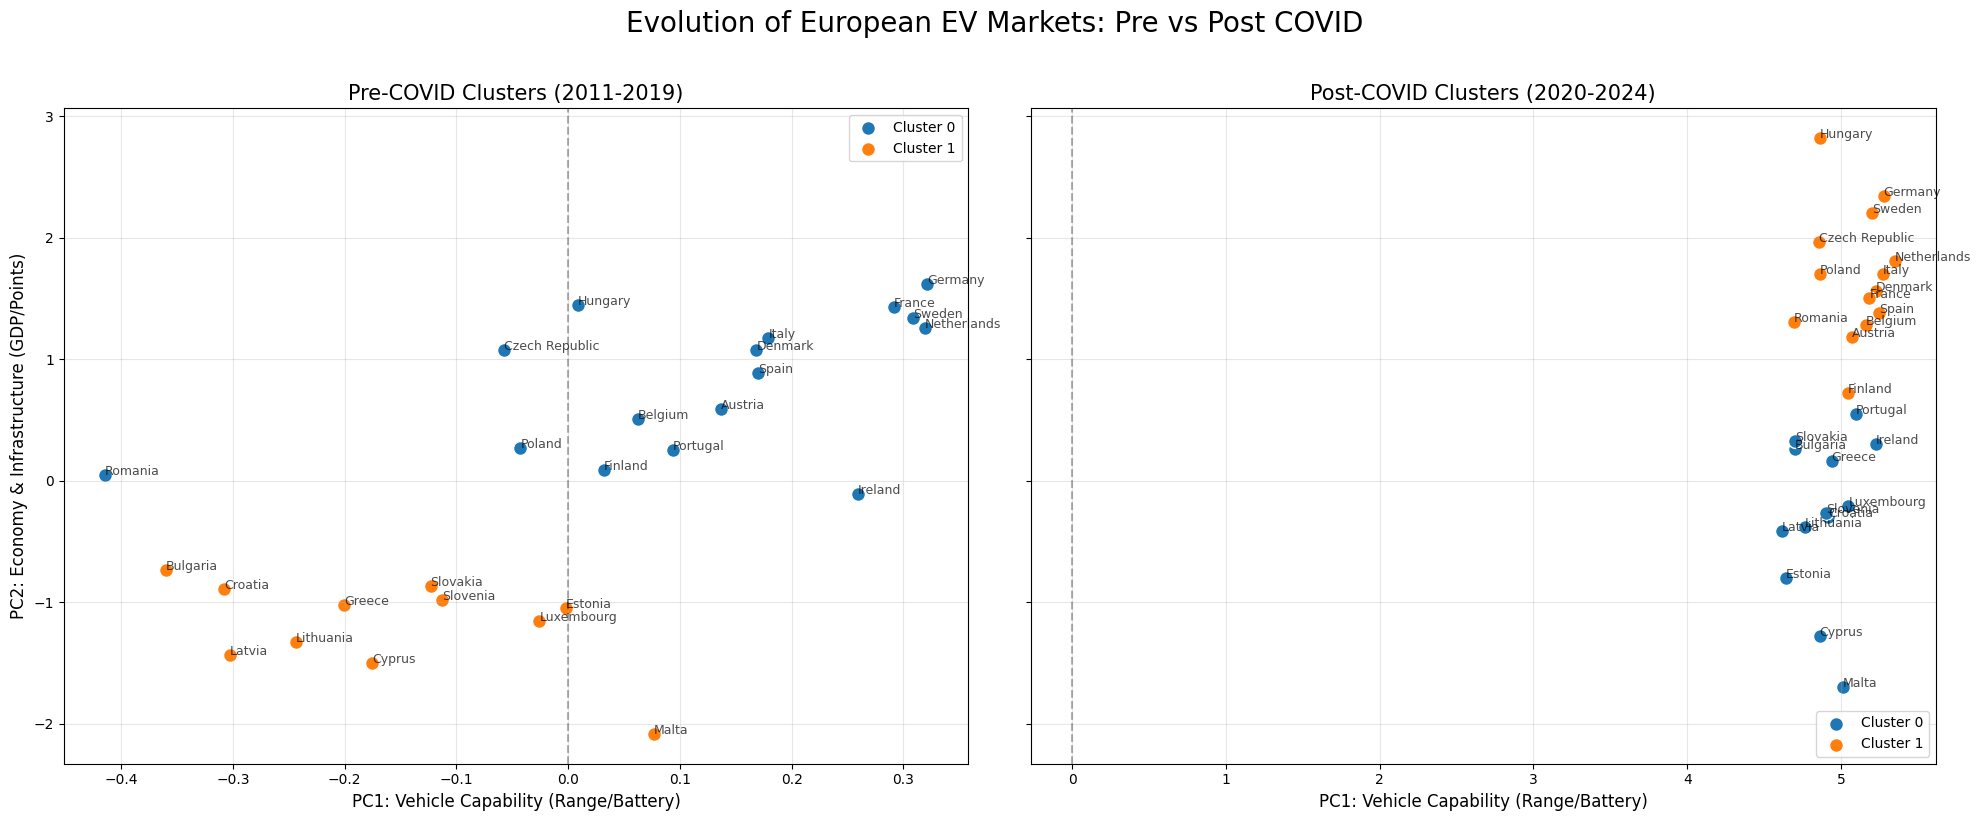

In [35]:
# Create the Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Pre-COVID
for cluster in [0, 1]:
    subset = pre_plot_data[pre_plot_data['Cluster'] == cluster]
    ax1.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', s=100, edgecolors='white')

# Add country labels using the index
for country in pre_plot_data.index:
    row = pre_plot_data.loc[country]
    ax1.text(row['PC1'], row['PC2'], country, fontsize=9, alpha=0.7)

ax1.set_title('Pre-COVID Clusters (2011-2019)', fontsize=15)
ax1.set_xlabel('PC1: Vehicle Capability (Range/Battery)', fontsize=12)
ax1.set_ylabel('PC2: Economy & Infrastructure (GDP/Points)', fontsize=12)
ax1.axvline(0, color='black', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Post-COVID
for cluster in [0, 1]:
    subset = post_plot_data[post_plot_data['Cluster'] == cluster]
    ax2.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', s=100, edgecolors='white')

# Add country labels using the index
for country in post_plot_data.index:
    row = post_plot_data.loc[country]
    ax2.text(row['PC1'], row['PC2'], country, fontsize=9, alpha=0.7)

ax2.set_title('Post-COVID Clusters (2020-2024)', fontsize=15)
ax2.set_xlabel('PC1: Vehicle Capability (Range/Battery)', fontsize=12)
ax2.axvline(0, color='black', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Evolution of European EV Markets: Pre vs Post COVID', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

**Explanation**

**1. For PC1:** In the Pre-COVID plot, the data is clusters around 0. In the Post-COVID plot, the entire market has moved to the left, centering around -5.

This means that, PC1 representing 'Vehicle Capabilities' proves that the "average" BEVs currently (2024) is statistically superior to the BEVs in 2019 by 5 standard deviations. Maybe COVID was a boon to these "follower" countries and the baseline for these factors shifted and the "followers" upgraded themselves.

**2. For PC2:** In the Pre-COVID plot, countries are spread widely along the y-axis (from -1.5 to +2). In the Post-COVID plot, the points are more tightly packed vertically.

This vertical compression means that the "Infrastructure Gap" like recharging points is narrowing. Developing EV markets (lower GDP) are catching up in terms of charging points, making them look more similar to the wealthier nations than they did a decade ago.

**For stable countries - Ireland and Portugal**

Pre-COVID, they are in the blue cluster and remains there Post-COVID. This tells us that they transitioned into a different economic family.

Ireland and Portugal moved up in the y-axis joining the "Leaders" clusters upgrading their Infrastructures. On the other hand, "Leaders" in the Pre-COVID era like Germany, Netherlands and France, earlier in the blue clusters changed to orange clusters which shows that they slowed down in the manufacturing and we here it all over the news everyday :)

**Note:** In the Pre-COVID plot, "High Tech" was on the right (positive). In the Post-COVID plot, "High Tech" is on the left (more negative). This confirms your PCA weights are negative for vehicle quality.

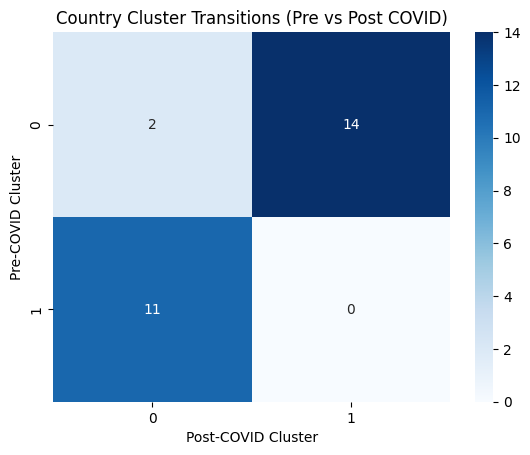

In [36]:
# Heatmap to visualize cluster transitions
ct = pd.crosstab(cluster_compare['Pre_COVID_Cluster'], cluster_compare['Post_COVID_Cluster'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Country Cluster Transitions (Pre vs Post COVID)')
plt.xlabel('Post-COVID Cluster')
plt.ylabel('Pre-COVID Cluster')
plt.show()

## 2. DBSCAN

**Parameters:**
1. eps=1.2: A point is a neighbor if the distance is <= 1.2
2. min_samples=2: A cluster needs at least 2 countries to exist

In [37]:
# Pre-COVID clustering by inititalising the clusters and fitiing the model on the pca averages
dbscan_pre = DBSCAN(eps=0.8, min_samples=2)
pre_plot_data['DBSCAN_Cluster'] = dbscan_pre.fit_predict(X_pre_pca)

# Post-COVID clustering
dbscan_post = DBSCAN(eps=0.8, min_samples=2)
post_plot_data['DBSCAN_Cluster'] = dbscan_post.fit_predict(X_post_pca)

In [38]:
print("Pre-COVID Cluster Characteristics:")
pre_characteristics = pre_plot_data.groupby('DBSCAN_Cluster')[['PC1', 'PC2', 'PC3']].mean()
display(pre_characteristics)

print("Post-COVID Cluster Characteristics:")
post_characteristics = post_plot_data.groupby('DBSCAN_Cluster')[['PC1', 'PC2', 'PC3']].mean()
display(post_characteristics)

Pre-COVID Cluster Characteristics:


,PC1,PC2,PC3
DBSCAN_Cluster,,,
-1,0.077031,-2.083820,1.240632
0,0.114733,0.810371,-0.092484
1,-0.185297,-1.096181,0.001076


Post-COVID Cluster Characteristics:


,PC1,PC2,PC3
DBSCAN_Cluster,,,
-1,5.013209,-1.696772,1.453839
0,4.988518,0.824632,0.574568


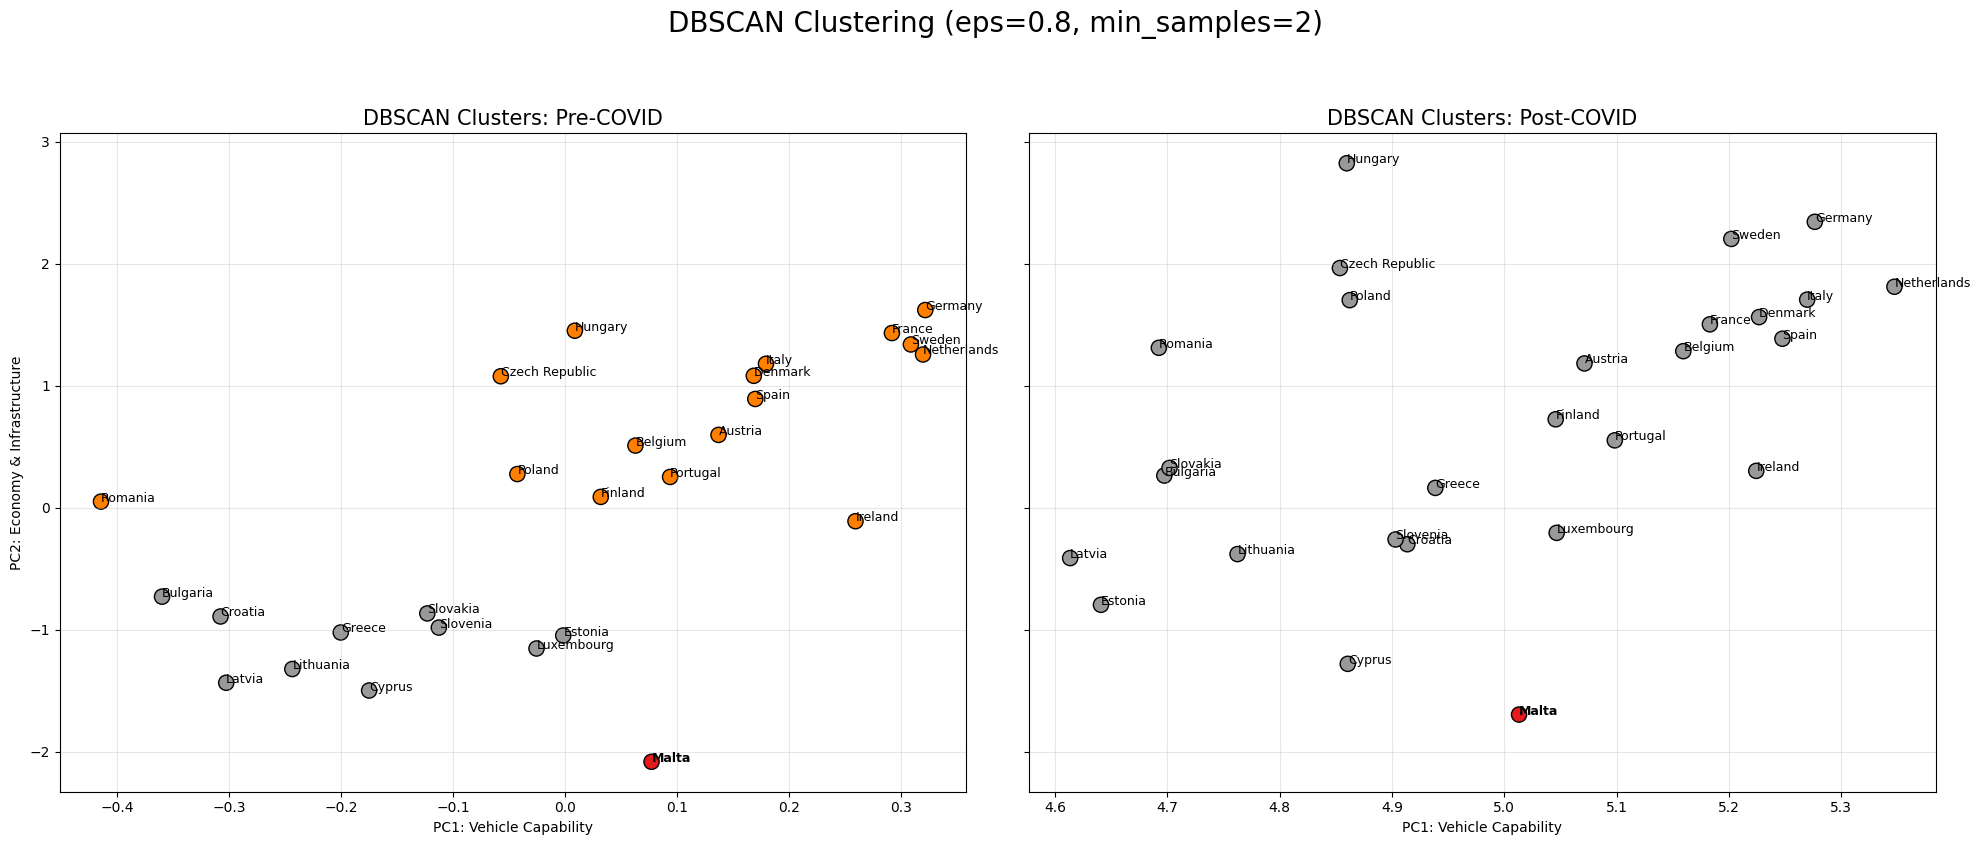

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Pre-COVID visualisation
# Plot clusters and noise (-1)
scatter1 = ax1.scatter(pre_plot_data['PC1'], pre_plot_data['PC2'],
                       c=pre_plot_data['DBSCAN_Cluster'], cmap='Set1', s=120, edgecolors='black')

# Annotate Country names from the index
for country in pre_plot_data.index:
    ax1.text(pre_plot_data.loc[country, 'PC1'], pre_plot_data.loc[country, 'PC2'],
             country, fontsize=9, fontweight='bold' if country == 'Malta' else 'normal')

ax1.set_title('DBSCAN Clusters: Pre-COVID', fontsize=15)
ax1.set_xlabel('PC1: Vehicle Capability')
ax1.set_ylabel('PC2: Economy & Infrastructure')
ax1.grid(True, alpha=0.3)

# Post-COVID visualisation
scatter2 = ax2.scatter(post_plot_data['PC1'], post_plot_data['PC2'],
                       c=post_plot_data['DBSCAN_Cluster'], cmap='Set1', s=120, edgecolors='black')

# Annotate Country names
for country in post_plot_data.index:
    ax2.text(post_plot_data.loc[country, 'PC1'], post_plot_data.loc[country, 'PC2'],
             country, fontsize=9, fontweight='bold' if country == 'Malta' else 'normal')

ax2.set_title('DBSCAN Clusters: Post-COVID', fontsize=15)
ax2.set_xlabel('PC1: Vehicle Capability')
ax2.grid(True, alpha=0.3)

# 4. Final touches
plt.suptitle(f'DBSCAN Clustering (eps=0.8, min_samples=2)', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [40]:
# Merge Pre and Post COVID results on the Country index
dbscan_comparison = pre_plot_data[['DBSCAN_Cluster']].merge(
    post_plot_data[['DBSCAN_Cluster']],
    left_index=True,
    right_index=True,
    suffixes=('_Pre', '_Post')
)

In [41]:
# Countries that changed clusters
dbscan_changed = dbscan_comparison[dbscan_comparison['DBSCAN_Cluster_Pre'] != dbscan_comparison['DBSCAN_Cluster_Post']]
print(f"Total Countries that Changed Clusters: {len(dbscan_changed)}")
display(dbscan_changed)

Total Countries that Changed Clusters: 10


,DBSCAN_Cluster_Pre,DBSCAN_Cluster_Post
Bulgaria,1,0
Croatia,1,0
Cyprus,1,0
Estonia,1,0
Greece,1,0
Latvia,1,0
Lithuania,1,0
Luxembourg,1,0
Slovakia,1,0
Slovenia,1,0


In [42]:
# Countries that were stable
dbscan_stable = dbscan_comparison[dbscan_comparison['DBSCAN_Cluster_Pre'] == dbscan_comparison['DBSCAN_Cluster_Post']]
print(f"Total Stable Countries: {len(dbscan_stable)}")
display(dbscan_stable)

Total Stable Countries: 17


,DBSCAN_Cluster_Pre,DBSCAN_Cluster_Post
Austria,0,0
Belgium,0,0
Czech Republic,0,0
Denmark,0,0
Finland,0,0
France,0,0
Germany,0,0
Hungary,0,0
Ireland,0,0
Italy,0,0


## Justification

**1. Elimination of Multicollinearity via PCA**

The original dataset of 18 indicators (raw and their corresponding transformed version) which exhibited high multicollinearity, with several Variance Influence Factor (VIF) values exceeding 5 (as per literature). In ther literature, pre-PCA clustering was performed and then choosing the a **Clustering Algorithm Design** i.e. PCA + Heirarchial Clustering. We on the other hand, skipped the pre-PCA clsutering and directly performed Principal Component Analysis (PCA) first. The features were transformed into uncorrelated Principal Components (PCs), which effectively eliminated these linear dependencies of the clustering algorithm  (PCA + K-Means), as evidenced by the VIF for Principal Components which was 1.0 (independent of each other).

**2. Selection of K-Means for Cluster Stability**  

Used elbow method for determining the #of Clusters and validated it by Silhouette Score.

**3. Rejection of DBSCAN Clustering Model**

In the literature the authors explicitly tested DBSCAN during their baseline phase. They found that it produced a negative Silhouette score (-0.05). This means that the clusters are overlapping or that the "noise" is so high that the groups aren't meaningful.

In my analysis, the results show that after COVID-19, DBSCAN essentially collapsed 27 countries into one single large cluster and one outlier (Malta). While this is an interesting observation of "market convergence," it is useless for a thesis that needs to identify different market profiles like "Leaders" and "Followers".

**4. Data Reduction and Scenario Scalability**

The chosen methodology allowed for the reduction of 27 EU countries into a manageable framework of 2 clusters. This simplification makes comparisons between similar countries more meaningful and significantly reduces the computational and data requirements for scenario analysis.

**5. Prevention of Data Leakage**

The goal was to observe how the model builds Pre-COVID dataset and then how it behaves when it encounters the Post-COVID dataset. By using only Pre-COVID data to establish your initial cluster definitions, a strict temporal boundary is built that allowed to treat the Post-COVID data as a completely independent validation set.

## For Geopandas Visualisation

In [43]:
# Read Europe shapefile from GeoJSON (countries only)
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)

print(world.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry'], dtype='object')


In [44]:
# List of European countries
europe_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"
]

# Replace 'name' with whatever column actually contains country names
europe = world[world['name'].isin(europe_countries)]

In [45]:
geo_data = europe.merge(dataset, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [46]:
print(geo_data.columns)

Index(['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country',
       'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)'],
      dtype='object')


In [47]:
# Create Pre-COVID summary
# We reset the index to turn 'Country' into a column and rename 'Cluster' to 'KMeans_Cluster'
pre_covid_summary = pre_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'DBSCAN_Cluster', 'KMeans_Cluster']]

# Create Post-COVID summary
post_covid_summary = post_plot_data.reset_index().rename(columns={
    'index': 'Country',
    'Cluster': 'KMeans_Cluster'
})[['Country', 'DBSCAN_Cluster', 'KMeans_Cluster']]

print("Pre-COVID K-Means and DBSCAN")
display(pre_covid_summary.head())
print()
print("Post-COVID K-Means and DBSCAN")
display(post_covid_summary.head())

Pre-COVID K-Means and DBSCAN


,Country,DBSCAN_Cluster,KMeans_Cluster
0,Austria,0,0
1,Belgium,0,0
2,Bulgaria,1,1
3,Croatia,1,1
4,Cyprus,1,1



Post-COVID K-Means and DBSCAN


,Country,DBSCAN_Cluster,KMeans_Cluster
0,Austria,0,1
1,Belgium,0,1
2,Bulgaria,0,0
3,Croatia,0,0
4,Cyprus,0,0


In [48]:
# Create a fresh copy of your main dataset
dataset_clusters = dataset.copy()

# Merge Pre-COVID clusters
dataset_clusters = dataset_clusters.merge(
    pre_covid_summary,
    on='Country',
    how='left'
).rename(columns={'DBSCAN_Cluster': 'DBSCAN_Pre', 'KMeans_Cluster': 'KMeans_Pre'})

# Merge Post-COVID clusters
dataset_clusters = dataset_clusters.merge(
    post_covid_summary,
    on='Country',
    how='left'
).rename(columns={'DBSCAN_Cluster': 'DBSCAN_Post', 'KMeans_Cluster': 'KMeans_Post'})

print("Merging complete. Columns in dataset_clusters:")
print(dataset_clusters.columns)

Merging complete. Columns in dataset_clusters:
Index(['Country', 'Year', 'BEV Percentage (Total Number Of Registrations)',
       'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points',
       'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available',
       'Battery Capacity', 'Real Range', 'Purchase price (EUR)',
       'Log_BEV Percentage (Total Number Of Registrations)',
       'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP',
       'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)',
       'YJ_Purchase price (EUR)', 'DBSCAN_Pre', 'KMeans_Pre', 'DBSCAN_Post',
       'KMeans_Post'],
      dtype='object')


In [49]:
geo_data = europe.merge(dataset_clusters, left_on='name', right_on='Country', how='left')
geo_data = gpd.GeoDataFrame(geo_data, geometry='geometry')

In [50]:
print(geo_data.columns.tolist())

['name', 'ISO3166-1-Alpha-3', 'ISO3166-1-Alpha-2', 'geometry', 'Country', 'Year', 'BEV Percentage (Total Number Of Registrations)', 'BEV (New Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points', 'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)', 'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)', 'Log_BEV Percentage (Total Number Of Registrations)', 'Log_BEV (New Registrations)', 'Log_Recharging Points', 'Log_GDP', 'Log_CPI', 'Log_Available', 'Log_DC Recharging Speed (km/h)', 'YJ_Purchase price (EUR)', 'DBSCAN_Pre', 'KMeans_Pre', 'DBSCAN_Post', 'KMeans_Post']


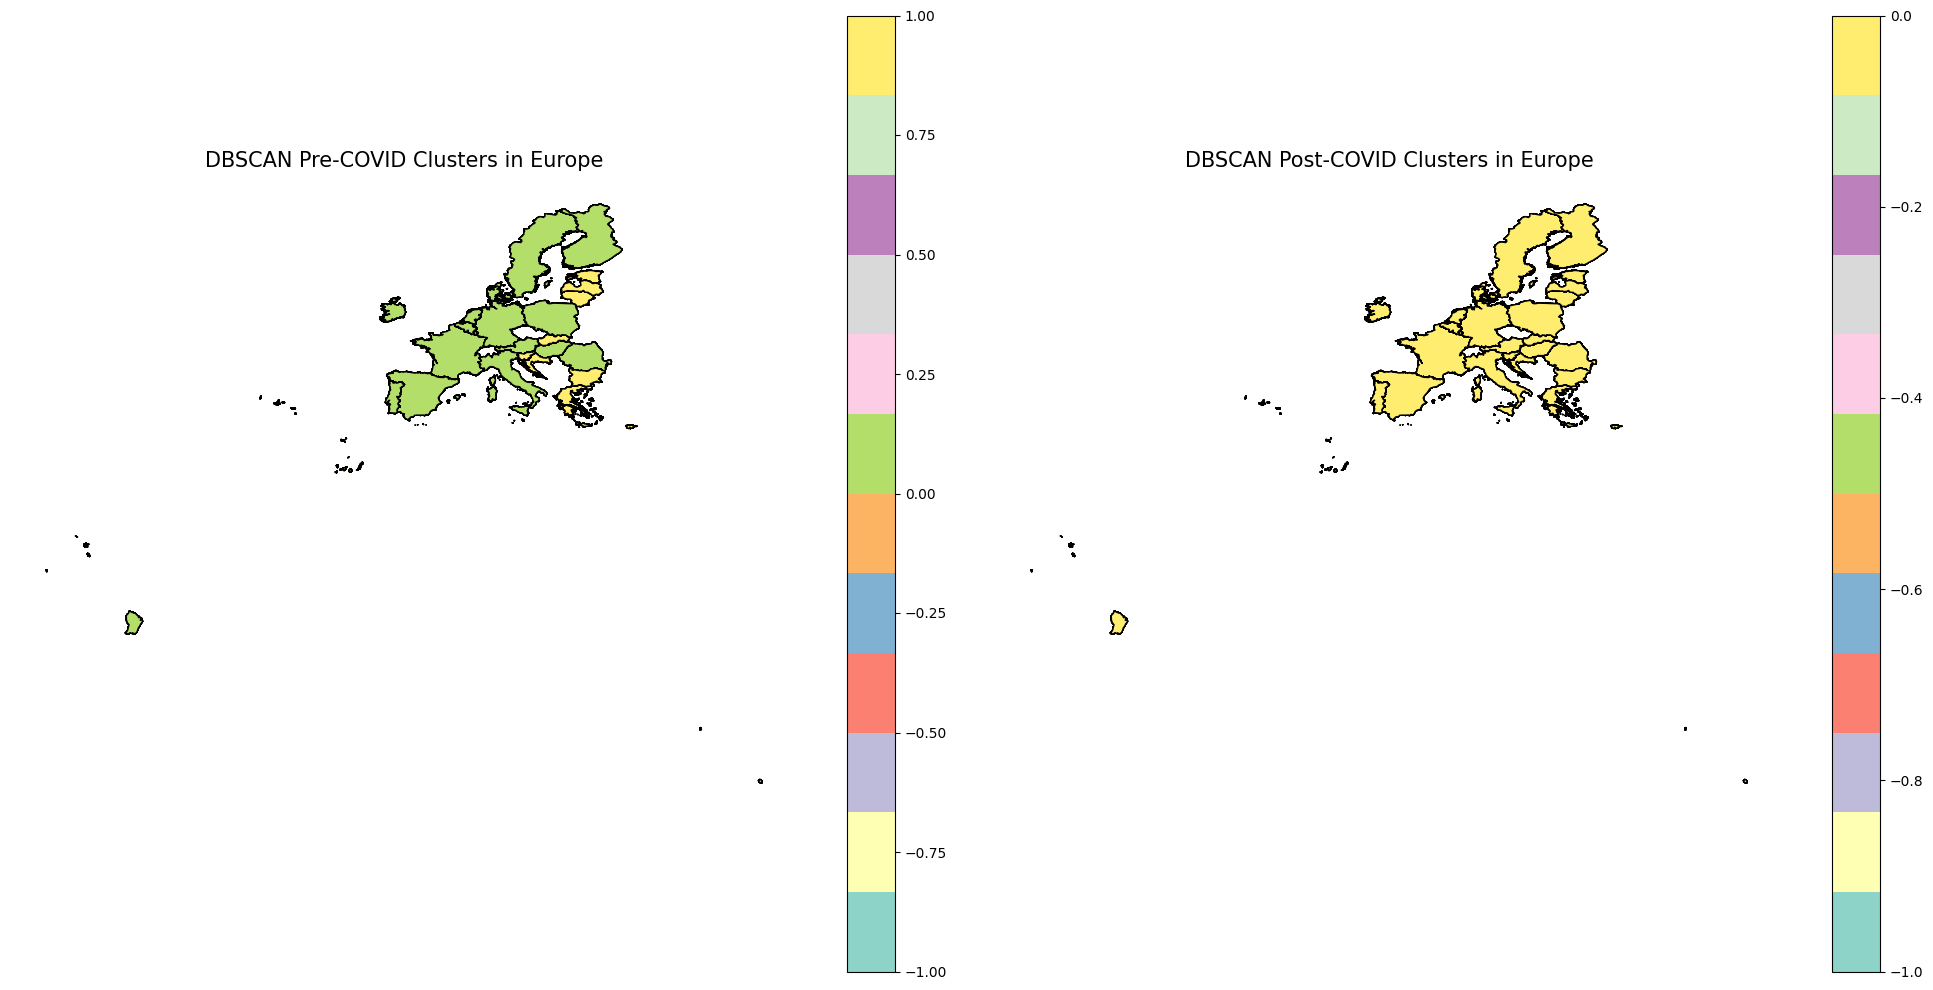

In [51]:
# DBSCAN: Pre- and Post-COVID
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Pre-COVID
geo_data.plot(column='DBSCAN_Pre',
              cmap='Set3',
              legend=True,
              ax=axes[0],
              edgecolor='black',
              missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
axes[0].set_title("DBSCAN Pre-COVID Clusters in Europe", fontsize=15)
axes[0].axis('off')

# Plot Post-COVID
geo_data.plot(column='DBSCAN_Post',
              cmap='Set3',
              legend=True,
              ax=axes[1],
              edgecolor='black',
              missing_kwds={'color': 'lightgrey', 'label': 'No Data'})
axes[1].set_title("DBSCAN Post-COVID Clusters in Europe", fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

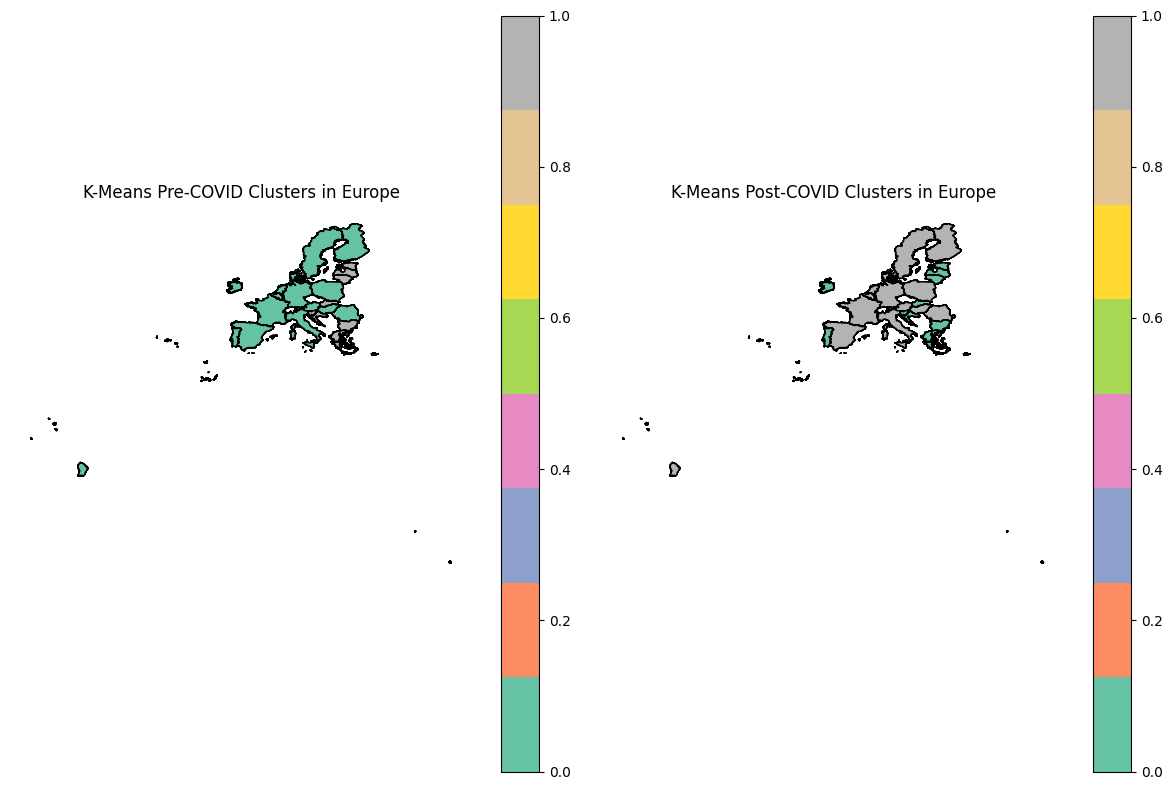

In [52]:
# K-Means: Pre- and Post-COVID

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

geo_data.plot(column='KMeans_Pre', cmap='Set2', legend=True, ax=axes[0], edgecolor='black')
axes[0].set_title("K-Means Pre-COVID Clusters in Europe")
axes[0].axis('off')

geo_data.plot(column='KMeans_Post', cmap='Set2', legend=True, ax=axes[1], edgecolor='black')
axes[1].set_title("K-Means Post-COVID Clusters in Europe")
axes[1].axis('off')

plt.tight_layout()
plt.show()

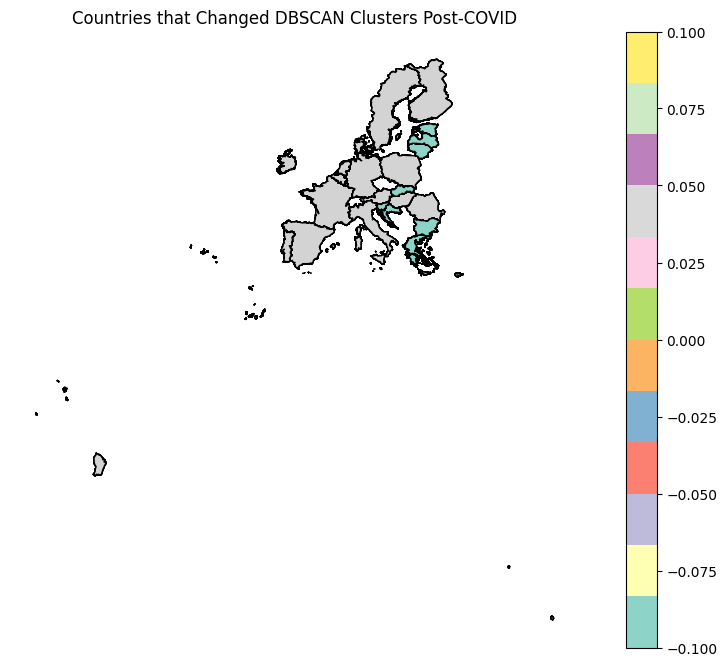

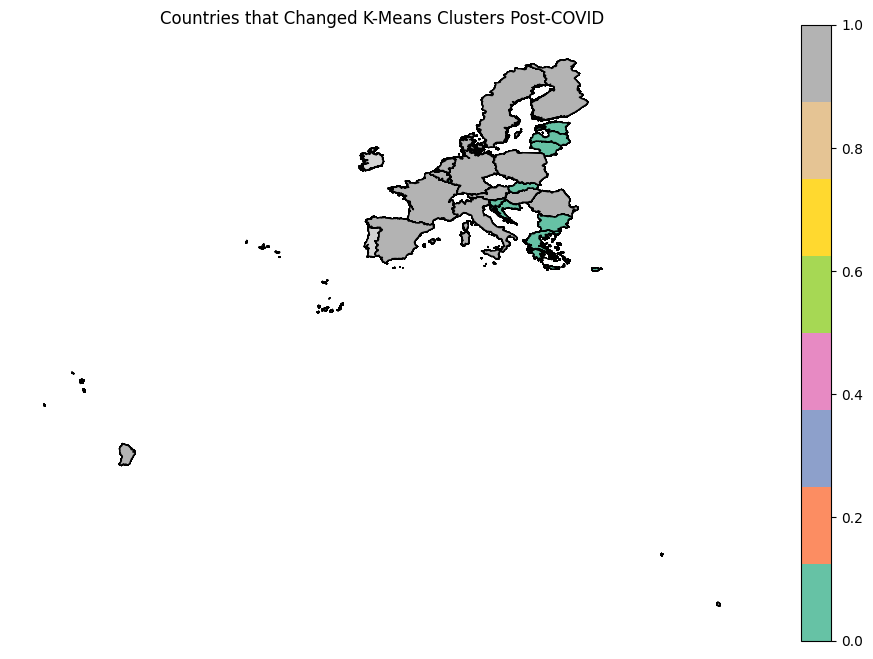

In [53]:
# Highlight countries that changed clusters

# Create change indicator columns
geo_data['DBSCAN_Change'] = geo_data['DBSCAN_Pre'] != geo_data['DBSCAN_Post']
geo_data['KMeans_Change'] = geo_data['KMeans_Pre'] != geo_data['KMeans_Post']

# DBSCAN change map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
geo_data.plot(color='lightgrey', edgecolor='black', ax=ax)
geo_data[geo_data['DBSCAN_Change']].plot(column='DBSCAN_Post', cmap='Set3', legend=True, ax=ax, edgecolor='black')
ax.set_title("Countries that Changed DBSCAN Clusters Post-COVID")
ax.axis('off')
plt.show()

# K-Means change map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
geo_data.plot(color='lightgrey', edgecolor='black', ax=ax)
geo_data[geo_data['KMeans_Change']].plot(column='KMeans_Post', cmap='Set2', legend=True, ax=ax, edgecolor='black')
ax.set_title("Countries that Changed K-Means Clusters Post-COVID")
ax.axis('off')
plt.show()